In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from collections import Counter

import scanpy as sc
import numpy as np

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

ANALYSIS_DIR = PROJECT_ROOT / "07_spatial_mouse_organogenesis"
DATA_DIR = PROJECT_ROOT / "data" / "flowmap_manuscript" / "mouse_organogenesis"
FIGURE_DIR = ANALYSIS_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(DATA_DIR / "SeqFISH_Embryo2_adata_SIRV_velocity.h5ad")

print(adata)
print("Layers:", adata.layers.keys())
print("obsm:", adata.obsm.keys())
Counter(adata.obs["celltype_mapped_refined"])


AnnData object with n_obs × n_vars = 14185 × 350
    obs: 'uniqueID', 'embryo', 'pos', 'z', 'x_global', 'y_global', 'x_global_affine', 'y_global_affine', 'embryo_pos', 'embryo_pos_z', 'Area', 'UMAP1', 'UMAP2', 'celltype_mapped_refined', 'n_counts', 'celltype', 'velocity_self_transition'
    var: 'GeneName', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'celltype_mapped_refined_colors', 'neighbors', 'pca', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_pca', 'X_umap', 'X_xy_loc'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'unspliced', 'variance_velocity', 'velocity'
    obsp: 'connectivities', 'distances'
Layers: KeysView(Layers with keys: Ms, Mu, spliced, unspliced, variance_velocity, velocity)
obsm: KeysView(AxisArrays with keys: X_pca, X_umap, X_xy_loc)


Counter({'Forebrain/Midbrain/Hindbrain': 4875,
         'Gut tube': 1650,
         'Cranial mesoderm': 1140,
         'Spinal cord': 1006,
         'Cardiomyocytes': 782,
         'Mixed mesenchymal mesoderm': 781,
         'Endothelium': 657,
         'Splanchnic mesoderm': 628,
         'Surface ectoderm': 535,
         'Neural crest': 494,
         'Haematoendothelial progenitors': 418,
         'Dermomyotome': 378,
         'Sclerotome': 266,
         'Anterior somitic tissues': 219,
         'Intermediate mesoderm': 179,
         'Erythroid': 99,
         'NMP': 32,
         'Definitive endoderm': 16,
         'Allantois': 15,
         'ExE endoderm': 6,
         'Blood progenitors': 5,
         'Lateral plate mesoderm': 3,
         'Presomitic mesoderm': 1})

In [2]:
from scipy.sparse import issparse

X_raw = adata.X
if issparse(X_raw):
    X_raw = X_raw.toarray()

V_raw = adata.layers["velocity"]
if issparse(V_raw):
    V_raw = V_raw.toarray()

X_emb = adata.obsm["X_xy_loc"]
X_emb = X_emb.astype(float)

In [3]:
from flowmap import *

emb = VectorFieldEmbedder(
    X_raw,
    V_raw,
    X_emb=X_emb,
    dist_method="phase",
    dof=30,
    n_spline_points=4000
)

emb.fit_embedding(seed=123)

/Users/jh/micromamba/envs/scvelo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[PCA] Projecting to 30 components …
[Spline] Fitting manifold spline on 4000 cells …
[Spline] Using all 4000 points as control points.
[Spline] Mapping vector field …
[Spline] Fitting velocity spline …
[Spline] Using all 4000 points as control points.
[FlowMap] Done.


In [4]:
simplify_map = {
    "Forebrain/Midbrain/Hindbrain": "Neural",
    "Spinal cord": "Neural",
    "Neural crest": "Neural",
    "NMP": "Neural",

    "Cranial mesoderm": "Mesoderm (Somitic)",
    "Dermomyotome": "Mesoderm (Somitic)",
    "Sclerotome": "Mesoderm (Somitic)",
    "Anterior somitic tissues": "Mesoderm (Somitic)",
    "Presomitic mesoderm": "Mesoderm (Somitic)",

    "Cardiomyocytes": "Mesoderm (LPM/Heart)",
    "Splanchnic mesoderm": "Mesoderm (LPM/Heart)",
    "Lateral plate mesoderm": "Mesoderm (LPM/Heart)",
    "Mixed mesenchymal mesoderm": "Mesoderm (LPM/Heart)",
    "Intermediate mesoderm": "Mesoderm (LPM/Heart)",

    "Gut tube": "Endoderm",
    "Definitive endoderm": "Endoderm",
    "ExE endoderm": "Endoderm",

    "Endothelium": "Endothelium/Blood",
    "Haematoendothelial progenitors": "Endothelium/Blood",
    "Blood progenitors": "Endothelium/Blood",
    "Erythroid": "Endothelium/Blood",

    "Surface ectoderm": "Surface ectoderm",

    "Allantois": "Allantois",
}

# Apply it
adata.obs["celltype_simplified"] = adata.obs["celltype_mapped_refined"].map(simplify_map)

Counter(adata.obs["celltype_simplified"])

Counter({'Neural': 6407,
         'Mesoderm (LPM/Heart)': 2373,
         'Mesoderm (Somitic)': 2004,
         'Endoderm': 1672,
         'Endothelium/Blood': 1179,
         'Surface ectoderm': 535,
         'Allantois': 15})

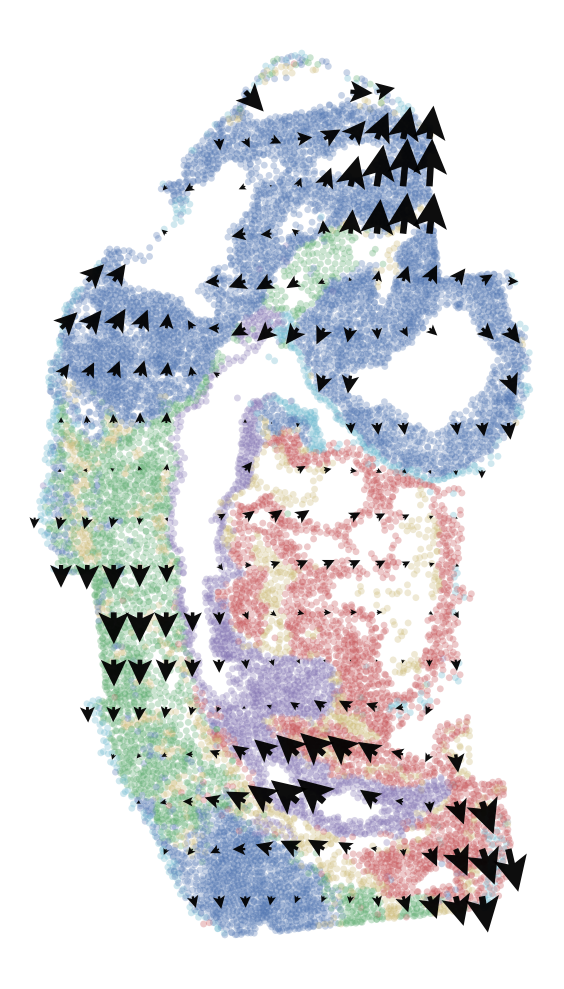

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from flowmap.utils import compute_velocity_on_grid


# ===============================================================
# Helper functions
# ===============================================================

def points_inside_mask(X_emb, seeds, k=8, radius_scale=1.2):
    nn = NearestNeighbors(n_neighbors=k).fit(X_emb)
    r = np.median(nn.kneighbors(X_emb, n_neighbors=k)[0][:, -1]) * radius_scale
    neigh_idx = nn.radius_neighbors(seeds, radius=r, return_distance=False)
    return np.array([len(ix) > 0 for ix in neigh_idx])


def add_manual_arrows(ax, coords, X_emb, V_pred,
                      color="k", scale=2.0, width=0.004):
    """Add optional manual arrows at chosen coords."""
    if len(coords) == 0:
        return ax

    nn = NearestNeighbors(n_neighbors=1).fit(X_emb)
    _, idx = nn.kneighbors(coords)
    idx = idx.ravel()

    ax.quiver(
        X_emb[idx, 0], X_emb[idx, 1],
        V_pred[idx, 0], V_pred[idx, 1],
        angles="xy", scale_units="xy", scale=3,
        width=0.003,
        headwidth=4.5, headlength=4.0, headaxislength=2.3,
        minlength=0.2,
        color=color, alpha=0.9
    )
    return ax


# ===============================================================
# 1) Embedding (spatial coords from FlowMap)
# ===============================================================
X_emb = emb.X_emb                         # spatial coordinates (already set)
labels = np.asarray(adata.obs["celltype_mapped_refined"].values)  # default


# ===============================================================
# 2) Simplified 7-category palette
# ===============================================================
# --- apply simplified labels ---
labels_simplified = labels.copy()
labels_simplified = np.array([simplify_map[l] for l in labels_simplified])

# --- 7-color high-quality palette ---
palette_simple = {
    "Neural": "#4C72B0",               # blue
    "Mesoderm (Somitic)": "#55A868",   # green
    "Mesoderm (LPM/Heart)": "#C44E52", # red
    "Endoderm": "#8172B2",             # purple
    "Endothelium/Blood": "#CCB974",    # tan
    "Surface ectoderm": "#64B5CD",     # cyan
    "Allantois": "#8C8C8C",            # gray
}

# --- turn into color array ---
cell_colors = np.array([palette_simple[l] for l in labels_simplified])


# ===============================================================
# 3) Grid seeds + TPS prediction
# ===============================================================
# compute grid on X_emb coordinates
Xg, keep_mass, _ = compute_velocity_on_grid(X_emb, grid_size=20, min_mass=0.01)

# mask seeds outside cell manifold
keep_inside = points_inside_mask(X_emb, Xg, k=8, radius_scale=1.2)
Xg = Xg[keep_inside]

# TPS prediction
Vg = emb.spline_vf.predict(Xg)

# full-cell predictions (for manual arrows)
V_cells = emb.spline_vf.predict(X_emb)


# ===============================================================
# 4) Plot
# ===============================================================
fig, ax = plt.subplots(figsize=(10, 10))

# scatter
ax.scatter(
    X_emb[:, 0], X_emb[:, 1],
    c=cell_colors, s=24, alpha=0.3, linewidths=0
)

# quiver (grid arrows)
ax.quiver(
    Xg[:, 0], Xg[:, 1],
    Vg[:, 0], Vg[:, 1],
    angles="xy", scale_units="xy",
    scale=120,
    width=0.012,
    headwidth=5.2,        # ↓ slightly smaller
    headlength=5.4,       # ↓ slightly smaller
    headaxislength=4.4,   # ↓ keeps proportions clean
    minlength=0.2,
    color="k", alpha=0.95
)

# optional manual arrows — EMPTY for now
patch_coords = []     # <<< placeholder
add_manual_arrows(ax, patch_coords, X_emb, V_cells)

ax.invert_yaxis()
# clean axes
ax.set_aspect("equal")
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()

# ===============================================================
# SAVE FIGURE
# ===============================================================
save_path = FIGURE_DIR / "embedding.pdf"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    transparent=True  # nice for papers
)

plt.show()

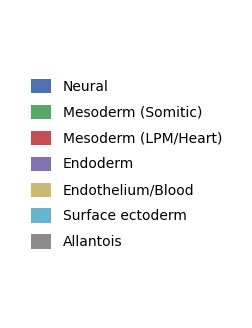

In [6]:
from matplotlib.patches import Patch

# --- build legend handles ---
handles = [
    Patch(facecolor=palette_simple[k], edgecolor='none', label=k)
    for k in palette_simple.keys()
]

# --- create separate legend figure ---
fig_legend = plt.figure(figsize=(3, 4))  # adjust as needed
ax = fig_legend.add_subplot(111)
ax.axis("off")

legend = ax.legend(
    handles=handles,
    loc="center",
    frameon=False,
    ncol=1,
    handlelength=1.5,
    handleheight=1.2,
    labelspacing=0.8,
    borderpad=0.2,
)

# --- save ---
legend_path = FIGURE_DIR / "legend.pdf"
import os

plt.savefig(
    legend_path,
    bbox_inches="tight",
    transparent=True
)

plt.show()

In [7]:
from flowmap.geometry import GeneGradientAnalyzer

# # ===============================================================
# # 0) Setup
# # ===============================================================
emb.fit_gene_level_splines(dof_gene=30, dof_vf_gene=30)
analyzer = GeneGradientAnalyzer(emb)

X_emb = analyzer.emb.X_emb
V_emb = analyzer.emb.V_emb

# --- use ALL cells ---
neighbor_indices = np.arange(X_emb.shape[0])

# --- genes ---
G = analyzer.emb.X_gene.shape[1]
gene_indices = np.arange(G)

# ===============================================================
# 1) Compute gradients (global)
# ===============================================================
res = analyzer.compute_relative_gradients(
    neighbor_indices=neighbor_indices,
    gene_indices=gene_indices,
    weight="magnitude",
)

[Spline-Gene] Fitting expression spline on 4000 cells …
[Spline] Using all 4000 points as control points.
[Spline-Gene] Mapping velocities …
[Spline-Gene] Fitting velocity spline …
[Spline] Using all 4000 points as control points.
[Spline-Gene] Done. X_gene (14185, 350), V_gene (14185, 350)
[GeneGradient] Computing expression Jacobians for 14185 cells x 350 genes …
[GeneGradient] Done. J (14185, 350, 2), metric (14185, 2, 2)



Top genes (by magnitude):

Hes3                 | magnitude=0.234 | angle= -19.35°
Hoxb9                | magnitude=0.200 | angle= -77.68°
Aldh1a2              | magnitude=0.181 | angle= -19.48°
Nepn                 | magnitude=0.127 | angle=-170.65°
En1                  | magnitude=0.113 | angle= -87.54°
Foxf1                | magnitude=0.110 | angle= 164.99°
Meis2                | magnitude=0.106 | angle=  -6.98°
Tbx1                 | magnitude=0.105 | angle=-179.66°
Irx3                 | magnitude=0.102 | angle=  -4.11°
Hoxd4                | magnitude=0.093 | angle= -90.64°
Hoxb1                | magnitude=0.091 | angle= -27.92°
Pax8                 | magnitude=0.088 | angle=-142.56°


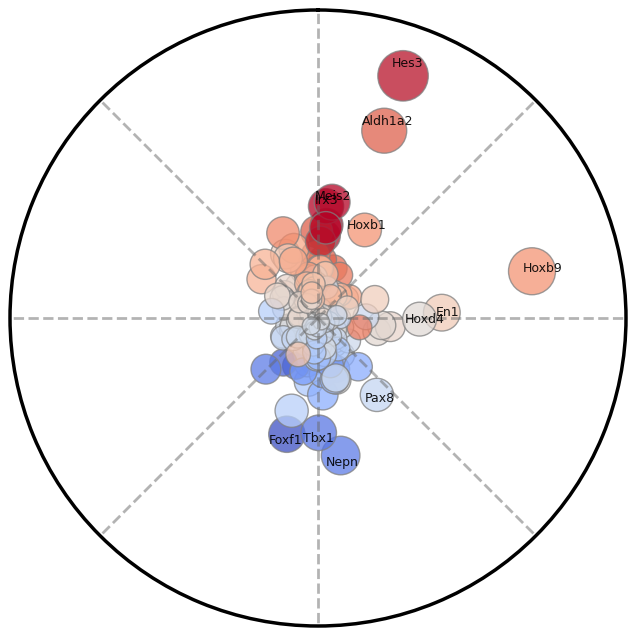

In [8]:
# ===============================================================
# 1) Inputs
# ===============================================================
analyzer.emb.gene_names = adata.var["GeneName"]

angles = res["angles"]              # (G,)
magnitudes = res["magnitudes"]      # (G,)

# remove NaNs
valid = np.isfinite(angles) & np.isfinite(magnitudes)
angles = angles[valid]
magnitudes = magnitudes[valid]
gene_indices = gene_indices[valid]

# ===============================================================
# 2) Rotate angles: 0 → up
# ===============================================================
scatter_angles = angles

# ===============================================================
# 3) Gene "velocity projection" (color)
# ===============================================================
J = analyzer.J[neighbor_indices]           # (N, G, 2)
V = V_emb[neighbor_indices]                # (N, 2)

vals_per_cell = np.einsum('cgd,cd->cg', J, V)   # (N, G)
vals = vals_per_cell.mean(axis=0)               # (G,)
vals = vals[valid]

# clip for visualization
cap = np.percentile(np.abs(vals), 99)
vals_clip = np.clip(vals, -cap, cap)

# ===============================================================
# 4) Sizes
# ===============================================================
sizes = 1200 * (magnitudes / (magnitudes.max() + 1e-8) + 0.1)

# ===============================================================
# 5) Polar plot
# ===============================================================
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))

# 0 at top now
ax.set_theta_zero_location('N')
ax.set_theta_direction(1)

# clean axes
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_rticks([])

# grid styling
ax.xaxis.grid(True, linestyle='--', color='dimgray', alpha=0.5, lw=2)
ax.yaxis.grid(True, linestyle='--', color='dimgray', alpha=0.5, lw=2)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(2.5)

# ===============================================================
# 6) Top genes
# ===============================================================
top_k = 12
top_idx = np.argsort(magnitudes)[-top_k:]

print("\nTop genes (by magnitude):\n")
for idx in top_idx[::-1]:
    gname = analyzer.emb.gene_names[gene_indices[idx]]

    ang = np.degrees(angles[idx])
    if ang > 180:
        ang -= 360

    print(f"{gname:20s} | magnitude={magnitudes[idx]:.3f} | angle={ang:7.2f}°")

# ===============================================================
# 7) Annotations
# ===============================================================
for idx in top_idx:
    theta = scatter_angles[idx]
    r = magnitudes[idx]
    gname = analyzer.emb.gene_names[gene_indices[idx]]

    ax.text(
        theta,
        r * 1.05,
        gname,
        fontsize=9,
        ha="center",
        va="center",
        color="black",
        alpha=0.9,
        clip_on=True,
    )

# ===============================================================
# 8) Scatter (with red/blue)
# ===============================================================
sc = ax.scatter(
    scatter_angles,
    magnitudes,
    s=sizes,
    c=vals_clip,
    cmap='coolwarm',
    vmin=-cap,
    vmax=cap,
    alpha=0.75,
    edgecolors="grey"
)

r_max = magnitudes.max()
r_lim = r_max * 1.2

ax.set_ylim(0, r_lim)

# ===============================================================
# 9) Save
# ===============================================================
plt.savefig(
    FIGURE_DIR / "gene_gradient_polar.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import flowmap

# ===============================================================
# 0) Output directory
# ===============================================================
outdir = FIGURE_DIR
outdir.mkdir(parents=True, exist_ok=True)

# ===============================================================
# 1) Select top genes (EDIT THIS if needed)
# ===============================================================
top_k = 12  # number of genes to export

# Example: using your previously computed magnitudes
top_idx = np.argsort(magnitudes)[-top_k:]
top_idx = top_idx[::-1]  # descending

gene_names = np.asarray(emb.gene_names)

# ===============================================================
# 2) Data + precompute
# ===============================================================
X_2d = emb.X_emb

expr_smooth = emb.spline_gene.predict(X_2d)              # (N, G)
jacobians   = emb.spline_gene.compute_jacobians(X_2d)    # (N, G, 2)

# optional: light outlier removal (shared across all plots)
r = np.linalg.norm(X_2d, axis=1)
keep = r < np.percentile(r, 99.5)

X_2d        = X_2d[keep]
expr_smooth = expr_smooth[keep]
jacobians   = jacobians[keep]

# ===============================================================
# 3) Loop over genes and save
# ===============================================================
for idx in top_idx:
    gname = gene_names[gene_indices[idx]]  # consistent with your earlier indexing

    # --- gradient field ---
    V_grad = jacobians[:, gene_indices[idx], :]   # (N, 2)

    # --- color = expression ---
    color = expr_smooth[:, gene_indices[idx]]

    # ===========================================================
    # Plot
    # ===========================================================
    fig, ax = plt.subplots(figsize=(5, 5))

    flowmap.plot.plot_velocity_stream(
        X_2d=X_2d,
        V=V_grad,
        scatter_color=color,
        grid_size=60,
        grid_density=1.0,
        stream_density=0.8,
        scatter_size=10,
        scatter_alpha=0.05,
        arrowsize=1.2,
        streamline_thickness=3.5,
        cmap="viridis",      # or your cmap_dark
        title=None,          # no title
        show_axes=False,
        show_colorbar=False,
        ax=ax,
    )

    # ===========================================================
    # Save
    # ===========================================================
    fname = f"{gname}.png"
    fpath = os.path.join(outdir, fname)

    plt.savefig(
        fpath,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.close(fig)

print(f"Saved {len(top_idx)} gene plots to: {outdir}")

[Spline] Subsampling 4000/14114 points for fitting …
[Spline] Using all 4000 points as control points.
[Spline] Subsampling 4000/14114 points for fitting …
[Spline] Using all 4000 points as control points.
[Spline] Subsampling 4000/14114 points for fitting …
[Spline] Using all 4000 points as control points.
[Spline] Subsampling 4000/14114 points for fitting …
[Spline] Using all 4000 points as control points.
[Spline] Subsampling 4000/14114 points for fitting …
[Spline] Using all 4000 points as control points.
[Spline] Subsampling 4000/14114 points for fitting …
[Spline] Using all 4000 points as control points.
[Spline] Subsampling 4000/14114 points for fitting …
[Spline] Using all 4000 points as control points.
[Spline] Subsampling 4000/14114 points for fitting …
[Spline] Using all 4000 points as control points.
[Spline] Subsampling 4000/14114 points for fitting …
[Spline] Using all 4000 points as control points.
[Spline] Subsampling 4000/14114 points for fitting …
[Spline] Using all 4

In [10]:
def compute_gene_gradients_per_cell(emb, g_idx):

    X = emb.X_emb
    V = emb.V_emb

    J = emb.spline_gene.compute_jacobians(X)
    metric = emb.spline_gene.compute_metric(X)

    n_cells = X.shape[0]

    angles = []
    magnitudes = []

    for c_idx in range(n_cells):

        g = metric[c_idx]
        J_cell = J[c_idx]
        v = V[c_idx]

        grad = np.linalg.solve(g, J_cell[g_idx])

        L = np.linalg.cholesky(g + 1e-8 * np.eye(g.shape[0]))

        grad_E = L @ grad
        vel_E = L @ v

        v_norm = np.linalg.norm(vel_E)
        if v_norm < 1e-8:
            angles.append(np.nan)
            magnitudes.append(0)
            continue

        e1 = vel_E / v_norm
        e2 = np.array([-e1[1], e1[0]])

        comp_parallel = grad_E @ e1
        comp_orth = grad_E @ e2

        vec = np.array([comp_parallel, comp_orth])

        angle = np.arctan2(vec[1], vec[0])
        mag = np.linalg.norm(vec)

        angles.append(angle)
        magnitudes.append(mag)

    return np.array(angles), np.array(magnitudes)

In [11]:
def plot_polar_gradients(angles, magnitudes, gene_ids, gene_names):

    import matplotlib.pyplot as plt
    import numpy as np

    fig = plt.figure(figsize=(5, 5))
    ax = plt.subplot(111, polar=True)

    # optional: normalize magnitudes for visualization
    r = magnitudes / (np.percentile(magnitudes, 95) + 1e-8)

    # color by gene
    unique_genes = np.unique(gene_ids)
    cmap = plt.cm.tab20

    for i, g in enumerate(unique_genes):
        mask = gene_ids == g

        ax.scatter(
            angles[mask],
            r[mask],
            s=8,
            alpha=0.6,
            color=cmap(i % 20),
            label=gene_names[g] if i < 10 else None  # avoid legend explosion
        )

    # reference directions
    ax.axvline(0, color="red", linewidth=2)         # along velocity
    ax.axvline(np.pi/2, color="gray", linestyle="--")  # orthogonal
    ax.axvline(-np.pi/2, color="gray", linestyle="--")

    ax.set_title("Gradient vs Velocity Direction", fontsize=12)

    # optional legend
    if len(unique_genes) <= 10:
        ax.legend(bbox_to_anchor=(1.2, 1.0))

    plt.tight_layout()
    plt.show()

In [ ]:
genes_selected = ["Hes3", "Hoxb9", "Nepn", "Aldh1a2", "En1", "Tbx1"]

gene_to_idx = {g: i for i, g in enumerate(emb.gene_names)}
gene_indices = np.array([gene_to_idx[g] for g in genes_selected])


# ===============================================================
# 5) Plot: one polar subplot per gene
# ===============================================================
n = len(gene_indices)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig = plt.figure(figsize=(12, 8))

for i, g in enumerate(genes_selected):

    g_idx = gene_to_idx[g]
    angles, magnitudes = compute_gene_gradients_per_cell(emb, g_idx)

    r = magnitudes / (np.percentile(magnitudes, 95) + 1e-8)

    ax = plt.subplot(2, 3, i + 1, polar=True)

    valid = ~np.isnan(angles)

    ax.scatter(
        angles[valid],
        r[valid],
        c=cell_colors[valid],
        s=6,
        alpha=0.7
    )

    ax.axvline(0, color="red", linewidth=2)
    ax.axvline(np.pi/2, color="gray", linestyle="--")
    ax.axvline(-np.pi/2, color="gray", linestyle="--")

    ax.set_title(g, fontsize=11)
    ax.set_yticklabels([])
    ax.set_xticklabels([])

plt.tight_layout()

# ===============================================================
# 6) Save
# ===============================================================
out_path = FIGURE_DIR / "velocity_gradient_polar_genes.png"

plt.savefig(
    out_path,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()